# External Feature Engineering

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import camelot



## events

In [74]:
!ls ../data/external

Verbraucherpreisindex.csv
_repo_intake_review_NON_FINAL
demographics_and_labor_market_by_zip_2025_rural.csv
demographics_labour_final.csv
einwohnerstatistik-31.12.2025.csv
event_data.csv
football.csv
gathered_poulataion_statistics_by_zipcode.csv
oil_price.csv
stac-statjahrbuch-2024.pdf


In [75]:
events = pd.read_csv('../data/external/event_data.csv', sep=';')

events.info()
print('--'*20)
display(events.sample(8))
print('Count Events:', events.event.nunique())
print('Events:', events.event.unique().tolist())

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    49 non-null     str  
 1   event   49 non-null     str  
dtypes: str(2)
memory usage: 2.2 KB
----------------------------------------


,date,event
29,2025-07-03,CHIO Aachen
35,2026-05-24,CHIO Aachen
9,2025-03-16,WeinAachen
22,2025-05-09,vocatium Aachen
23,2025-06-27,CHIO Aachen
5,2025-09-23,Stadtfest
4,2025-09-22,Stadtfest
11,2025-03-23,EUREGIO Wirtschaftsschau


Count Events: 7
Events: ['Stadtfest', 'WeinAachen', 'EUREGIO Wirtschaftsschau', 'Karrieretag Aachen', 'vocatium Aachen', 'CHIO Aachen', 'EUREGIO Wirtschaftsschau 2026']


In [76]:
# mapping zipcode

mapping = {
    "Stadtfest": "52062",
    "WeinAachen": "52062",
    "EUREGIO Wirtschaftsschau": "52070",
    "Karrieretag Aachen": "52062",
    "vocatium Aachen": "52062",
    "CHIO Aachen": "52070",
    "EUREGIO Wirtschaftsschau 2026": "52070",
}

events['zipcode'] = events.event.map(mapping)
display(events.sort_values('date'))
events.zipcode.unique()

,date,event,zipcode
8,2025-03-15,WeinAachen,52062
9,2025-03-16,WeinAachen,52062
10,2025-03-22,EUREGIO Wirtschaftsschau,52070
11,2025-03-23,EUREGIO Wirtschaftsschau,52070
12,2025-03-24,EUREGIO Wirtschaftsschau,52070
13,2025-03-25,EUREGIO Wirtschaftsschau,52070
14,2025-03-26,EUREGIO Wirtschaftsschau,52070
15,2025-03-27,EUREGIO Wirtschaftsschau,52070
16,2025-03-28,EUREGIO Wirtschaftsschau,52070
17,2025-03-29,EUREGIO Wirtschaftsschau,52070


<ArrowStringArray>
['52062', '52070']
Length: 2, dtype: str

In [77]:
# dtpyes change
events['date'] = pd.to_datetime(events['date'])
events['event'] = events['event'].astype('category')
events['zipcode'] = events['zipcode'].astype('category')

print(events.info())
events.head()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     49 non-null     datetime64[us]
 1   event    49 non-null     category      
 2   zipcode  49 non-null     category      
dtypes: category(2), datetime64[us](1)
memory usage: 822.0 bytes
None


,date,event,zipcode
0,2025-09-18,Stadtfest,52062
1,2025-09-19,Stadtfest,52062
2,2025-09-20,Stadtfest,52062
3,2025-09-21,Stadtfest,52062
4,2025-09-22,Stadtfest,52062


In [78]:
# write to disc
events.to_parquet('../data/processed/events_transformed.parquet', index=False, )

## soccer

In [164]:
soccer_raw = pd.read_csv('../data/external/football.csv', sep=',', index_col=0)

# home games
display(soccer_raw.sort_values('matchDateTime').head(2))

# zipcode stadion 52070
soccer = soccer_raw[['matchDateTime', 'team1.shortName' ]]
soccer['zipcode'] = 52070


,matchID,matchDateTime,timeZoneID,leagueId,leagueName,leagueSeason,leagueShortcut,matchDateTimeUTC,lastUpdateDateTime,matchIsFinished,matchResults,goals,location,numberOfViewers,group.groupName,group.groupOrderID,group.groupID,team1.teamId,team1.teamName,team1.shortName,team1.teamIconUrl,team1.teamGroupName,team2.teamId,team2.teamName,team2.shortName,team2.teamIconUrl,team2.teamGroupName,location.locationID,location.locationCity,location.locationStadium
14,78269,2025-08-09T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-09T12:00:00Z,2025-08-10T15:13:35.52,True,"[{'resultID': 118370, 'resultName': 'Halbzeit'...","[{'goalID': 130299, 'scoreTeam1': 0, 'scoreTea...",NaN,NaN,2. Spieltag,2,48789,23,Alemannia Aachen,Aachen,https://upload.wikimedia.org/wikipedia/commons...,NaN,2396,TSG 1899 Hoffenheim II,TSG 1899 Hoffenheim II,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN
24,78281,2025-08-23T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-23T12:00:00Z,2025-08-23T17:19:52.08,True,"[{'resultID': 118522, 'resultName': 'Halbzeit'...","[{'goalID': 130602, 'scoreTeam1': 0, 'scoreTea...",NaN,NaN,3. Spieltag,3,48790,23,Alemannia Aachen,Aachen,https://upload.wikimedia.org/wikipedia/commons...,NaN,125,TSV 1860 München,1860 München,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN


In [165]:
soccer.head()

,matchDateTime,team1.shortName,zipcode
14,2025-08-09T14:00:00,Aachen,52070
24,2025-08-23T14:00:00,Aachen,52070
46,2025-09-13T16:30:00,Aachen,52070
64,2025-09-20T14:00:00,Aachen,52070
84,2025-09-30T19:00:00,Aachen,52070


In [166]:
# rmoving time from match time
soccer['matchDateTime'] = pd.to_datetime(soccer.matchDateTime).dt.date
soccer['matchDateTime'] = pd.to_datetime(soccer.matchDateTime)

# adding is_homegame
soccer['soccer_home_game'] = 'is_home_game'

# removeing team name
soccer = soccer.drop('team1.shortName', axis=1).reset_index(drop=True)

soccer.head()

,matchDateTime,zipcode,soccer_home_game
0,2025-08-09,52070,is_home_game
1,2025-08-23,52070,is_home_game
2,2025-09-13,52070,is_home_game
3,2025-09-20,52070,is_home_game
4,2025-09-30,52070,is_home_game


In [170]:
# export to csv
soccer.to_csv('../data/processed/soccer_25.csv', index=False)

## oil price

In [81]:
oil_price = pd.read_csv('../data/external/oil_price.csv')
oil_price = oil_price[2:].rename(columns={'Price': 'Date'})
oil_price.info()
oil_price.Date.max()
oil_price.head()
print('std:', oil_price.High.astype('float64').std())
# volume?

<class 'pandas.DataFrame'>
RangeIndex: 354 entries, 2 to 355
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    354 non-null    str  
 1   Close   354 non-null    str  
 2   High    354 non-null    str  
 3   Low     354 non-null    str  
 4   Open    354 non-null    str  
 5   Volume  354 non-null    str  
dtypes: str(6)
memory usage: 45.0 KB
std: 14.40105795094324


In [82]:
oil_price['Date'] = pd.to_datetime(oil_price['Date'])
oil_price['High'] = oil_price['High'].astype('float64')
oil_price.head(2)

,Date,Close,High,Low,Open,Volume
2,2025-01-02,73.12999725341797,73.730003,71.79000091552734,71.8499984741211,306498
3,2025-01-03,73.95999908447266,74.349998,72.69999694824219,73.12999725341797,296040


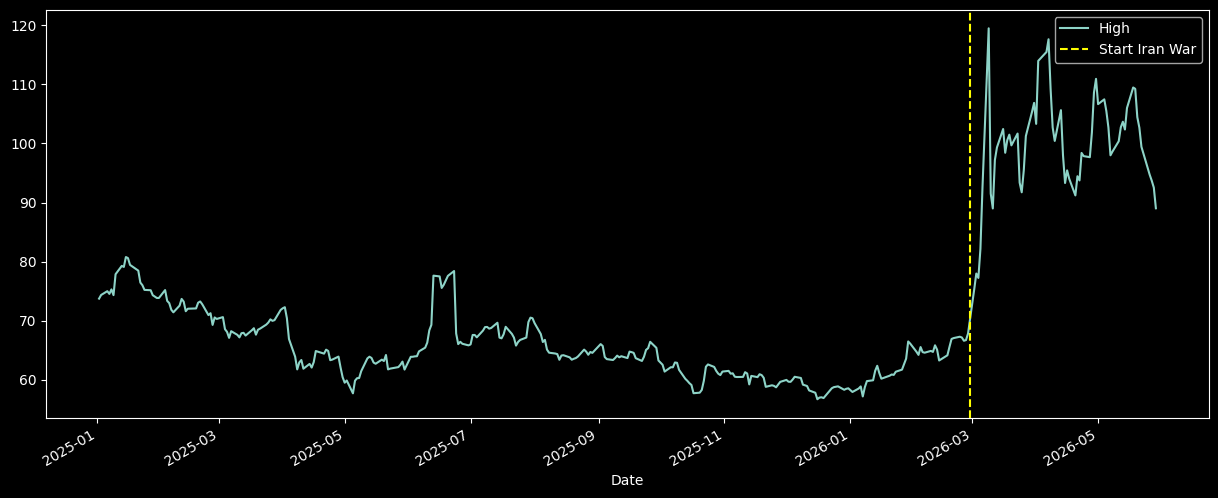

In [83]:
plt.style.use('dark_background')
oil_price.plot(kind='line', x='Date', y='High', figsize=(15,6))
plt.axvline('2026-02-28', linestyle="--", color='yellow', label='Start Iran War')
plt.legend()
plt.show()

In [84]:
##  load base df from file
df = pd.read_parquet('../data/processed/02_df_cleaned.parquet', engine='pyarrow')
df.head()

,store_id,item_id,date,category_name,sold_quantity,revenue,zipcode,holiday_name,holiday_type,wind_dir,weather_code,temperature,wind_speed,wind_degree,precip,humidity,visibility,pressure,cloudcover,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_sum_7,rolling_sum_28,expanding_mean,price_rounded
0,0,5,2025-02-01,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,SE,113,1.7,7.300000,115.900002,0.0,75.099998,10.0,1030.099976,2.900000,0.0,1.0,1.0,1.0,0.142857,0.377964,0.142857,0.363137,0.107143,0.314970,1.0,3.0,0.001224,10.5
1,0,5,2025-03-15,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,NE,116,2.5,15.400000,42.500000,0.0,71.000000,9.0,1017.500000,49.599998,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.001604,10.5
2,0,5,2025-03-29,Kuchen,1.0,10.50,52062,no_holiday,no_holiday,NNW,176,7.4,14.200000,324.500000,0.1,70.599998,9.0,1018.000000,53.500000,0.0,0.0,1.0,0.0,0.000000,0.000000,0.071429,0.267261,0.035714,0.188982,0.0,1.0,0.001994,10.5
3,0,5,2025-05-17,Kuchen,1.0,11.25,52062,no_holiday,no_holiday,N,113,11.5,8.500000,304.399994,0.0,71.300003,8.0,1019.400024,24.799999,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.002347,11.2
4,0,5,2025-05-24,Kuchen,1.0,11.25,52062,no_holiday,no_holiday,SSW,116,10.1,19.700001,214.199997,0.2,74.800003,8.9,1016.500000,78.099998,0.0,1.0,0.0,0.0,0.142857,0.377964,0.071429,0.267261,0.035714,0.188982,1.0,1.0,0.002731,11.2


In [85]:
rolls = df[(df.category_name == 'Brötchen') & (df.date > '2025-06-01')]
rolls_by_date = rolls.groupby(['category_name', 'date'])['revenue'].agg(['sum', 'mean', 'std']).reset_index().sort_values('date')
display(rolls_by_date.head(2))
for c in df.category_name.unique():
    print(c)


,category_name,date,sum,mean,std
0,Brötchen,2025-06-02,67002.601562,35.830269,48.237026
1,Brötchen,2025-06-03,62555.464844,33.362915,45.045677


Kuchen
Snack
Brot
Brötchen
Feinbäckerei
Kaltgetränke 19%
Heißgetränke
Angebot Brot
Printen/Kekse
Konditorei
Snack Belag
Angebot Snack
Angebot Brötchen 
Angebot Gastro
Kaltgetränke 7%
Angebot Feinbäckerei
Angebot Kuchen
Angebot Heißgetränke
Eigerichte
Printen Waage
Frühstücke
Gastro Gerichte
Angebot Konditorei
Brotwaage


In [86]:
# plot oilprice vs revenue brötchen
oil_price_2026 = oil_price[oil_price.Date > '2025-06-01']
oil_price_2026

,Date,Close,High,Low,Open,Volume
105,2025-06-02,62.52000045776367,63.880001,61.060001373291016,61.11000061035156,403580
106,2025-06-03,63.40999984741211,63.889999,62.400001525878906,63.02000045776367,291260
107,2025-06-04,62.849998474121094,63.959999,62.16999816894531,63.36000061035156,321128
108,2025-06-05,63.369998931884766,63.980000,62.5,62.7599983215332,232423
109,2025-06-06,64.58000183105469,64.800003,62.81999969482422,63.33000183105469,310133
...,...,...,...,...,...,...
351,2026-05-22,96.5999984741211,99.430000,94.7300033569336,98.0,261142
352,2026-05-26,93.88999938964844,94.699997,89.41000366210938,93.87999725341797,358867
353,2026-05-27,88.68000030517578,93.690002,87.7699966430664,93.38999938964844,290948
354,2026-05-28,88.9000015258789,92.519997,87.11000061035156,89.11000061035156,235145


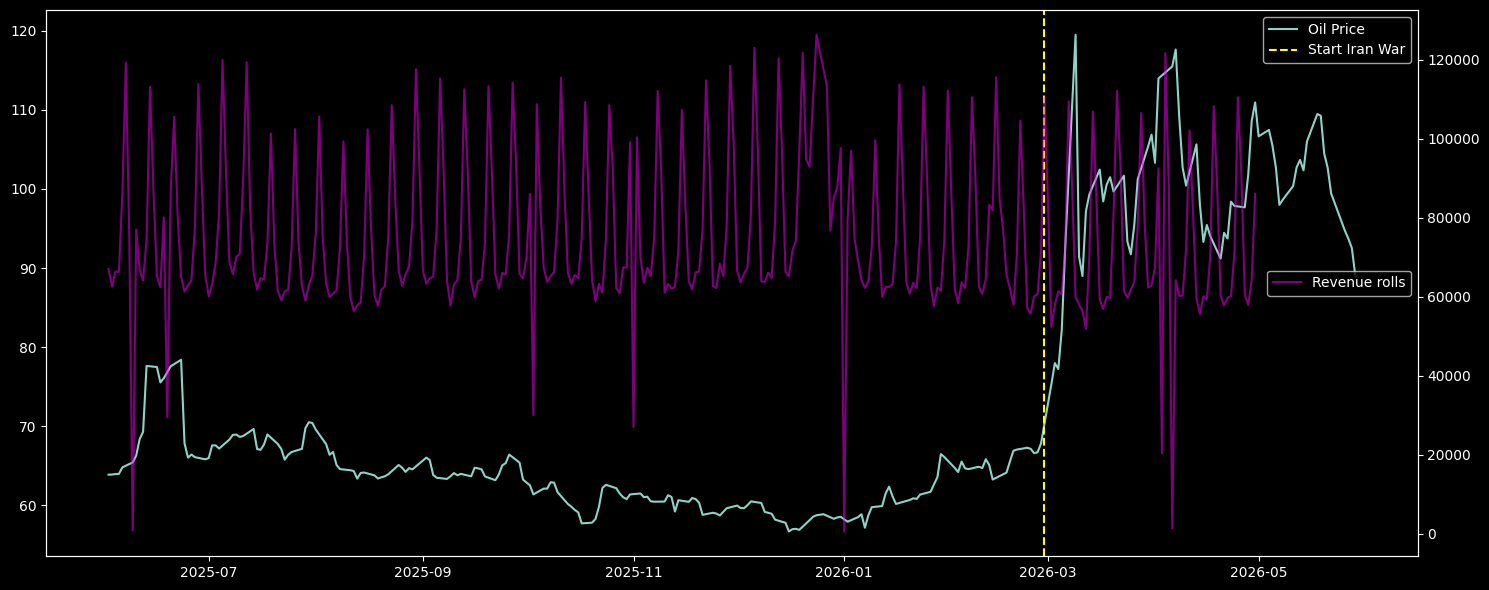

In [87]:
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(oil_price_2026.Date, oil_price_2026.High, label='Oil Price')
ax.axvline(pd.to_datetime('2026-02-28'), linestyle="--", color='yellow', label='Start Iran War')

# 2nd y axis
ax2 = ax.twinx()
ax2.plot(rolls_by_date.date, rolls_by_date['sum'], label='Revenue rolls', color='magenta', alpha=0.5)

ax.legend()
ax2.legend(loc=5)
plt.tight_layout()
plt.show()

# 2nd approach _canceled_
due to too much suggestions of Gemini

## population statistics 2023

In [88]:
# 2nd approach, 
# all populations data by zipcode in one csv
# data source gemini: https://share.google/aimode/UTrBeyDvqkuAItLjw

#m load data (leave total_purchaase power out, we are interessted in purchause power per capita)
population_2023_all = pd.read_csv('../data/external/gathered_poulataion_statistics_by_zipcode.csv')#.drop('total_purchasing_power_yearly', axis=1)

In [89]:
for col in population_2023_all.columns:
    print(col)

zip_code
area_sqkm
pop_density_per_sqkm
total_purchasing_power_yearly
retail_purchasing_power
purchasing_power_per_capita
german_nationals
foreign_nationals
age_0_18
age_18_35
age_35_65
age_over_65
working_age_population
employees_social_security
unemployed
status_single
status_married
status_divorced_widowed
estimated_students


feature groups

0. pop_density_per sqkm

1. purchasing power
   * total_purchasing_power_yearly
   * retail_purchasing_power, 
   * purchasing_power_per_capita


2. german vs non-german
   * german_nationals
   * foreign_nationals
3. age groups
    * age_0_18
    * age_18_35
    * age_35_65
    * age_over_65
   +  working_age_population
  
4. employment status
    * employees_social_security
    * unemployed
6. marital status

    * status_single
    * status_married
    * status_divorced_widowed

7. students

   * estimated_students

,zip_code,area_sqkm,pop_density_per_sqkm,total_purchasing_power_yearly,retail_purchasing_power,purchasing_power_per_capita,german_nationals,foreign_nationals,age_0_18,age_18_35,age_35_65,age_over_65,working_age_population,employees_social_security,unemployed,status_single,status_married,status_divorced_widowed,estimated_students
0,52062,1.64,5793,224200000,73980000,23600,7410,2090,1140,3515,3325,1520,6840,3690,580,5415,2850,1235,2800
1,52064,3.12,8974,711200000,227500000,25400,22960,5040,3920,8960,10920,4200,19880,11330,1490,14560,9800,3640,7800


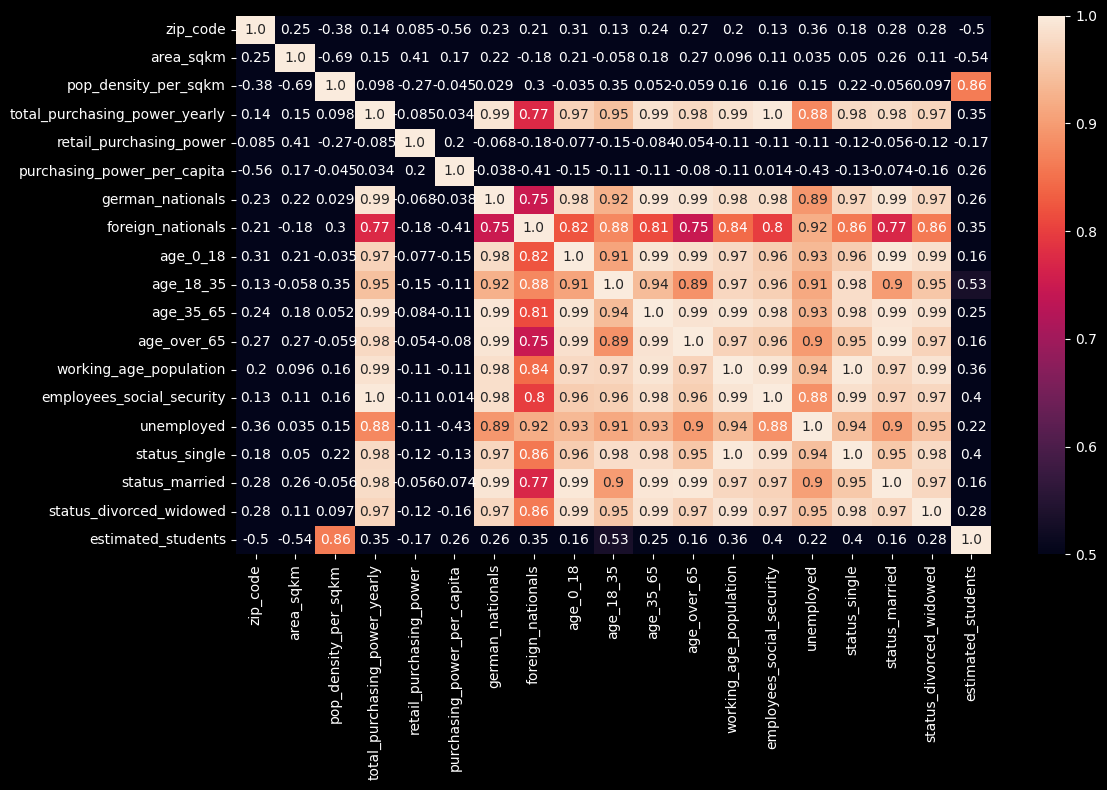

In [90]:
display(population_2023_all.head(2))
plt.figure(figsize=(12,8))
sns.heatmap(population_2023_all.corr(), annot=True, vmin=0.5, fmt=".2")
plt.tight_layout()
plt.show()

# 3rd approach

## population statistics / opendata aachen 2025/24

#### Rural Region Aachen

In [91]:
# zipcode mapping rural aachen area

zipcode_surrounding = {
    "52224": "Stolberg (Rheinland)",
    "52134": "Herzogenrath",
    "52222": "Stolberg (Rheinland)",
    "52379": "Langerwehe",
    "52146": "Würselen",
    "52249": "Eschweiler",
    "52477": "Alsdorf",
    "52223": "Stolberg (Rheinland)",
    "52499": "Baesweiler",
    "52428": "Jülich",
    "52152": "Simmerath",
    "52531": "Übach-Palenberg",
    "52159": "Roetgen",
    "52156": "Monschau",
    "52382": "Niederzier",
    "52351": "Düren"
}

sorted(list(zipcode_surrounding.items()))

[('52134', 'Herzogenrath'),
 ('52146', 'Würselen'),
 ('52152', 'Simmerath'),
 ('52156', 'Monschau'),
 ('52159', 'Roetgen'),
 ('52222', 'Stolberg (Rheinland)'),
 ('52223', 'Stolberg (Rheinland)'),
 ('52224', 'Stolberg (Rheinland)'),
 ('52249', 'Eschweiler'),
 ('52351', 'Düren'),
 ('52379', 'Langerwehe'),
 ('52382', 'Niederzier'),
 ('52428', 'Jülich'),
 ('52477', 'Alsdorf'),
 ('52499', 'Baesweiler'),
 ('52531', 'Übach-Palenberg')]

In [92]:
# demographic and labor data rural aachen
# source Gemini: https://share.google/aimode/UmmuqdovnJYDCIIa0

rural_2025 = pd.read_csv('../data/external/demographics_and_labor_market_by_zip_2025_rural.csv')
rural_2025.head()

,zipcode,total_population,single,married,divorced_widowed,german_citizens,non_german_citizens,under_20_years,20_to_64_years,65_years_older,subject_to_social_security_svb,unemployed,population_density
0,52062,28632.0,21824.0,5015.0,598.0,17837.0,10795.0,2779.0,23153.0,2700.0,12540.0,1350.0,6818
1,52064,26434.0,19299.0,5120.0,778.0,18924.0,7510.0,2740.0,20669.0,3025.0,11580.0,1240.0,5471
2,52066,25742.0,15328.0,7771.0,997.0,20733.0,5009.0,3707.0,17631.0,4404.0,11280.0,1210.0,4115
3,52068,11292.0,6853.0,3081.0,505.0,5721.0,5571.0,2054.0,7622.0,1616.0,4950.0,530.0,3427
4,52070,29784.0,19649.0,7201.0,1097.0,19094.0,10690.0,4493.0,21437.0,3854.0,13040.0,1400.0,3819


#### City Region Aachen

In [93]:
# load data Aachen city
pd.set_option('display.max_columns', None)
population_2025 = pd.read_csv('../data/external/einwohnerstatistik-31.12.2025.csv', sep=',', encoding='latin1')
population_2025.head()


,Bez,StatBezName,Pers_ insges,HW,NW,M,W,LD,VH,VW,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,Deutsch,Ausl
0,10.0,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0
1,13.0,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0
2,14.0,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0
3,15.0,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0
4,16.0,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0


In [94]:
# synchrnoize rural and city data, adjust header names and order of columns

# compute new age groups spans (like in rural data)
population_2025['under_20_years'] = population_2025['0-2'] + population_2025['3-5'] + population_2025['6-9'] + population_2025['10-14'] + population_2025['15-17'] + population_2025['18-19']
population_2025['20_to_64_years'] = population_2025['20-24'] + population_2025['25-29'] + population_2025['30-34'] + population_2025['35-39'] + population_2025['40-44'] + population_2025['45-49'] + population_2025['50-54'] + population_2025['55-59'] + population_2025['60-64']
population_2025['65_years_older'] = population_2025['65-69'] + population_2025['70-74'] + population_2025['75-79'] + population_2025['80-84'] + population_2025['85-89'] + population_2025['90um']



In [95]:
# translate population data to english
print(population_2025.columns)
print(rural_2025.columns)

new_names = {
    'Pers_ insges': 'total_population' , 
    'LD': 'single',
    'VH': 'married',
    'VW': 'divorced_widowed', 
    'Deutsch': 'german_citizens', 
    'Ausl': 'non_german_citizens' 
}

population_2025 = population_2025.rename(columns=new_names)



Index(['Bez', 'StatBezName', 'Pers_ insges', 'HW', 'NW', 'M', 'W', 'LD', 'VH',
       'VW', 'GS', 'RK', 'EV', '0-2', '3-5', '6-9', '10-14', '15-17', '18-19',
       '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59',
       '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90um', 'Deutsch',
       'Ausl', 'under_20_years', '20_to_64_years', '65_years_older'],
      dtype='str')
Index(['zipcode', 'total_population', 'single', 'married', 'divorced_widowed',
       'german_citizens', 'non_german_citizens', 'under_20_years',
       '20_to_64_years', '65_years_older', 'subject_to_social_security_svb',
       'unemployed', 'population_density'],
      dtype='str')


In [96]:
# get municipal distric names
#population_2025.StatBezName.str.strip().unique().tolist()

# mapping list with zipcode (thanks CHatGPT)
district_zipcode = {
    'Markt': '52062',
    'Theater': '52062',
    'Lindenplatz': '52064',
    'St. Jakob': '52064',
    'Westpark': '52064',
    'Hanbruch': '52074',
    'Hörn': '52074',
    'Ponttor': '52062',
    'Hansemannplatz': '52070',
    'Soers': '52070',
    'Jülicher Str.': '52070',
    'Jülicher Straße': '52070',
    'Kalkofen': '52070',
    'Kaiserplatz': '52062',
    'Adalbertsteinweg': '52070',
    'Panneschopp': '52068',
    'Rothe Erde': '52068',
    'Trierer Str.': '52078',
    'Trierer Straße': '52078',
    'Frankenberg': '52066',
    'Forst': '52078',
    'Beverau': '52066',
    'Burtsch. Kurgarten': '52066',
    'Burtscheider Kurgarten': '52066',
    'Burtscheider Abtei': '52066',
    'Steinebrück': '52080',
    'Marschiertor': '52064',
    'Hangeweiher': '52074',
    'Brand': '52078',
    'Eilendorf': '52080',
    'Haaren': '52080',
    'Kornelimünster': '52076',
    'Oberforstbach': '52076',
    'Walheim': '52076',
    'Vaalserquartier': '52074',
    'Laurensberg': '52072',
    'Richterich': '52072',
    'STADT AACHEN': '52000',  # Sammelwert / ggf. NaN verwenden
}


# adding zipcode to data set
population_2025.insert(1, 'zipcode', population_2025.StatBezName.str.strip().map(district_zipcode), allow_duplicates=False)
population_2025.head()

,Bez,zipcode,StatBezName,total_population,HW,NW,M,W,single,married,divorced_widowed,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,german_citizens,non_german_citizens,under_20_years,20_to_64_years,65_years_older
0,10.0,52062,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0,209.0,2334.0,291.0
1,13.0,52062,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0,281.0,2628.0,350.0
2,14.0,52064,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0,347.0,3309.0,579.0
3,15.0,52064,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0,598.0,5417.0,575.0
4,16.0,52064,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0,1099.0,6397.0,1087.0


In [97]:
# drop rest of columns not needed
cols_to_drop = ['0-2', '3-5', '6-9', '10-14', '15-17', '18-19',
       '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59',
       '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90um', 'HW', 'NW', 'M', 'W', 'GS', 'RK', 'EV', 'Bez', 'StatBezName' ]

population_2025 = population_2025.drop(columns=cols_to_drop)

In [98]:

#population_2025_transformed = population_2025[['zipcode', 'Pers_ insges', 'Deutsch', 'Ausl']]
#display(population_2025_transformed.sort_values('zipcode').head(2))
#population_2025_transformed.info()

In [99]:
population_2025_by_zipcode= population_2025.groupby('zipcode').sum()[1:].reset_index()

##  NOTE: to this result is added employees, unemployed and pop densitiy data by Gemini
# source: https://share.google/aimode/UmmuqdovnJYDCIIa0

In [100]:
population_2025_by_zipcode.head()

,zipcode,total_population,single,married,divorced_widowed,german_citizens,non_german_citizens,under_20_years,20_to_64_years,65_years_older
0,52062,28632.0,21824.0,5015.0,598.0,17837.0,10795.0,2779.0,23153.0,2700.0
1,52064,26434.0,19299.0,5120.0,778.0,18924.0,7510.0,2740.0,20669.0,3025.0
2,52066,25742.0,15328.0,7771.0,997.0,20733.0,5009.0,3707.0,17631.0,4404.0
3,52068,11292.0,6853.0,3081.0,505.0,5721.0,5571.0,2054.0,7622.0,1616.0
4,52070,29784.0,19649.0,7201.0,1097.0,19094.0,10690.0,4493.0,21437.0,3854.0


In [101]:
# write  to disc
#population_2025_transformed.to_parquet('../data/processed/population_2025_transformed.parquet', index=False)

#### Combining City and Rural Data__ -
Demographic and Labour Data for all zipcodes __finalized with Gemini__
> source: https://share.google/aimode/r8uvfvrUs19Trtc2D

In [102]:
# load  final demographic and labour data (csv created with Gemini)
demographics = pd.read_csv('../data/external/demographics_labour_final.csv')
demographics.head()

,zipcode,total_population,single,married,divorced_widowed,german_citizens,non_german_citizens,under_20_years,20_to_64_years,65_years_older,subject_to_social_security_svb,unemployed,population_density
0,52062,28632.0,21824.0,5015.0,598.0,17837.0,10795.0,2779.0,23153.0,2700.0,12540.0,1350.0,6818
1,52064,26434.0,19299.0,5120.0,778.0,18924.0,7510.0,2740.0,20669.0,3025.0,11580.0,1240.0,5471
2,52066,25742.0,15328.0,7771.0,997.0,20733.0,5009.0,3707.0,17631.0,4404.0,11280.0,1210.0,4115
3,52068,11292.0,6853.0,3081.0,505.0,5721.0,5571.0,2054.0,7622.0,1616.0,4950.0,530.0,3427
4,52070,29784.0,19649.0,7201.0,1097.0,19094.0,10690.0,4493.0,21437.0,3854.0,13040.0,1400.0,3819


## Competitors / Open Street Map

#### Open Street Map Data

In [103]:
# creat a function to query overpass API

def get_osm_bakery_count(zipcode: str, retries: int = 8) -> int:
    '''
    - Queries the OSM overpass API to count all shop=bakery in the given zipcode area
    - Returns an interger with the total count of bakeries in the given zipcode area

    Param:
        zipcode: str
        the zipcode of the area you want to search for bakeries provided as str

        retries: int
        how many retry queries to the overpass server are send. overpass is very unstable and quickly
        reaches a RATE_LIMIT
    '''

    zipcode = str(zipcode).strip()
    
    url = "https://overpass-api.de/api/interpreter"

    headers = { 
        "User-Agent": "PLZ-Bakery-Counter/1.0 (contact: marcel_junior@hotmail.com)"
    }

    # open street map API query code
    overpass_query = f'''
    [out:json][timeout:180];
    rel ["boundary"="postal_code"]["postal_code"="{zipcode}"];
    map_to_area->.plz_area;
    (
      nwr(area.plz_area)["shop"="bakery"];
    );
    out count;
    '''


    for i in range(retries):
        # query API
        response = requests.post(url, data={'data':overpass_query}, headers=headers, timeout=180)

        # unwanted returned status codes
        bad_status_codes = [429, 500, 501, 502, 503, 504]

        # waiting time increases if bad status code 
        if response.status_code in bad_status_codes:
            wait = 10 + i *5
            print(f"\t{response.status_code} → hard wait {wait}s")
            time.sleep(wait)
            continue

    
        # check for value errors in response
        try:
            result = response.json()
        except ValueError:
            return{
                'error': 'invalid json response',
                'text': response.text
            }
    
        # dig through json response to the actual count    
        bakery_count = int(result['elements'][0]['tags']['total'])

        return bakery_count




#### Query OSM
> Printing overview of cometitive bakeries

In [104]:
# get competitors

# function need zipcodes as string
zipcodes = demographics.zipcode.astype(str).unique()

# empty dict for later results
competitors = {}

#l = len(zipcodes)
#i = 1#

#for z in zipcodes:
#    print(f'{i}/{l}:\n')
#    print(z)
#    
#    # filter df for current zipcode
#    filtered = df[df.zipcode == z]#

#    # count unique stores within zipcode
#    store_count = filtered['store_id'].nunique()#

#    # count all osm bakeries by zipcode
#    osm_bakery_count = get_osm_bakery_count(z)#

#    # calculate competitors count
#    competitors_count = osm_bakery_count - store_count#

#    # print results
#    print(f'''
#    Stores: \t\t{store_count}
#    Competitors:  \t{competitors_count}
#    ----------------
#    ''')#

#    # add to dictionary 
#    competitors[z] = {"stores": store_count, "competitors": competitors_count, "osm_total": osm_bakery_count}#

#    # net iterate for enumeration only
#    i +=1
#    
#print('done')
#competitors

In [ ]:
# make dataframe and...
competitors_transformed = pd.DataFrame.from_dict(competitors, orient='index').reset_index().rename(columns={'index': 'zipcode'})

# ... export work in progress status (cause API call is relativly time consuming)
competitors_transformed.to_csv('../data/processed/competitors_transformed_intermediate.csv', index=False)

In [105]:
# load intermediate
competitors_transformed = pd.read_csv('../data/processed/competitors_transformed_intermediate.csv')

#### Create competitors market share and tier

In [106]:
# calulate competitor market share by zipcode
competitors_transformed['competitor_share'] = np.round(competitors_transformed['competitors'] /  competitors_transformed['osm_total'], 2)
competitors_transformed.sort_values('competitor_share', ascending=False)

,zipcode,stores,competitors,osm_total,competitor_share
3,52068,1,7,8,0.88
7,52076,1,6,7,0.86
20,52379,1,6,7,0.86
4,52070,2,10,12,0.83
12,52152,1,5,6,0.83
0,52062,4,20,24,0.83
16,52223,1,5,6,0.83
9,52080,2,9,11,0.82
14,52159,1,4,5,0.80
19,52351,1,4,5,0.80


In [35]:
# quantiles for competitor class rank
q1, q3 = competitors_transformed['competitor_share'].quantile([0.25, 0.75])
mini = competitors_transformed['competitor_share'].min()
maxi = competitors_transformed['competitor_share'].max()

print(mini, q1, q3, maxi)

# binning
competitors_transformed['competitor_class']  = pd.cut(x=competitors_transformed.competitor_share, 
                                                      bins=[mini, q1, q3, maxi], 
                                                      labels=['low', 'mid', 'high'], 
                                                      include_lowest=True )

competitors_transformed

0.25 0.67 0.8274999999999999 0.88


,zipcode,stores,competitors,osm_total,competitor_share,competitor_class
0,52062,4,20,24,0.83,high
1,52064,4,6,10,0.60,low
2,52066,4,12,16,0.75,mid
3,52068,1,7,8,0.88,high
4,52070,2,10,12,0.83,high
5,52072,2,4,6,0.67,low
6,52074,3,1,4,0.25,low
7,52076,1,6,7,0.86,high
8,52078,3,8,11,0.73,mid
9,52080,2,9,11,0.82,mid


In [107]:
# write to disc
competitors_transformed.to_csv('../data/processed/competitors_transformed.csv', index=False)

## Creating Sub-Dataframes for Model Testing

In [108]:
# population_density
pop_density_24 = demographics[['zipcode', 'population_density']]

# martial status
marital_status_24 = demographics[['zipcode', 'single', 'married', 'divorced_widowed']]

# germ vs. non-germ
german_non_24 = demographics[['zipcode', 'german_citizens', 'non_german_citizens']]

# age groups
age_groups_24 = demographics[['zipcode', 'under_20_years', '20_to_64_years', '65_years_older' ]]

# employed vs unemployed
un_employed_24 = demographics[['zipcode', 'unemployed', 'subject_to_social_security_svb']]

# competitors
competitor_bakeries_share_25 = competitors_transformed[['zipcode', 'competitor_share']]


In [37]:
# check

display(pop_density_24)
display(marital_status_24)
display(german_non_24)
display(age_groups_24)
display(un_employed_24)
display(competitor_share_25)


,zipcode,population_density
0,52062,6818
1,52064,5471
2,52066,4115
3,52068,3427
4,52070,3819
5,52072,1125
6,52074,1866
7,52076,446
8,52078,1952
9,52080,1434


,zipcode,single,married,divorced_widowed
0,52062,21824.0,5015.0,598.0
1,52064,19299.0,5120.0,778.0
2,52066,15328.0,7771.0,997.0
3,52068,6853.0,3081.0,505.0
4,52070,19649.0,7201.0,1097.0
5,52072,8322.0,8437.0,1276.0
6,52074,16502.0,10751.0,1616.0
7,52076,5934.0,7206.0,1141.0
8,52078,17865.0,16365.0,2367.0
9,52080,15482.0,14879.0,2273.0


,zipcode,german_citizens,non_german_citizens
0,52062,17837.0,10795.0
1,52064,18924.0,7510.0
2,52066,20733.0,5009.0
3,52068,5721.0,5571.0
4,52070,19094.0,10690.0
5,52072,16775.0,2711.0
6,52074,23602.0,7129.0
7,52076,14084.0,1420.0
8,52078,31286.0,8529.0
9,52080,29450.0,5895.0


,zipcode,under_20_years,20_to_64_years,65_years_older
0,52062,2779.0,23153.0,2700.0
1,52064,2740.0,20669.0,3025.0
2,52066,3707.0,17631.0,4404.0
3,52068,2054.0,7622.0,1616.0
4,52070,4493.0,21437.0,3854.0
5,52072,3383.0,10930.0,5173.0
6,52074,5114.0,18921.0,6696.0
7,52076,2901.0,8289.0,4314.0
8,52078,7877.0,22963.0,8975.0
9,52080,6449.0,20442.0,8454.0


,zipcode,unemployed,population_density
0,52062,1350.0,6818
1,52064,1240.0,5471
2,52066,1210.0,4115
3,52068,530.0,3427
4,52070,1400.0,3819
5,52072,920.0,1125
6,52074,1450.0,1866
7,52076,730.0,446
8,52078,1870.0,1952
9,52080,1660.0,1434


,zipcode,competitor_share
0,52062,0.83
1,52064,0.60
2,52066,0.75
3,52068,0.88
4,52070,0.83
5,52072,0.67
6,52074,0.25
7,52076,0.86
8,52078,0.73
9,52080,0.82


#### Export for modeling

In [38]:
# write to disc
pop_density_24.to_csv('../data/processed/pop_density_24.csv', index=False)

marital_status_24.to_csv('../data/processed/marital_status_24.csv', index=False)

german_non_24.to_csv('../data/processed/german_non_24.csv', index=False)

age_groups_24.to_csv('../data/processed/age_groups_24.csv', index=False)

un_employed_24.to_csv('../data/processed/un_employed_24.csv', index=False)

competitor_bakeries_share_25.to_csv('../data/processed/competitor_bakeries_share_25.csv', index=False)



# NOPE - 1st approach
> manual downloaded from different sources until we found out that AI (Gemini) finds all information much quciker -> see 3rd approach

## population / age groups 2025

In [43]:
population_2025.head()

,Bez,zipcode,StatBezName,Pers_ insges,HW,NW,M,W,LD,VH,VW,GS,RK,EV,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um,Deutsch,Ausl
0,10.0,52062,Markt,2834.0,2793.0,41.0,1618.0,1216.0,2161.0,468.0,74.0,131.0,799.0,323.0,31.0,29.0,25.0,37.0,17.0,70.0,630.0,679.0,372.0,177.0,114.0,95.0,85.0,87.0,95.0,78.0,64.0,45.0,44.0,40.0,20.0,1849.0,985.0
1,13.0,52062,Theater,3259.0,3230.0,29.0,1910.0,1349.0,2480.0,564.0,72.0,143.0,809.0,336.0,47.0,26.0,32.0,38.0,23.0,115.0,784.0,686.0,380.0,230.0,129.0,102.0,87.0,107.0,123.0,101.0,69.0,71.0,57.0,41.0,11.0,1977.0,1282.0
2,14.0,52064,Lindenplatz,4235.0,4205.0,30.0,2343.0,1892.0,3236.0,644.0,173.0,182.0,1230.0,508.0,40.0,44.0,52.0,61.0,36.0,114.0,905.0,968.0,489.0,243.0,162.0,112.0,126.0,158.0,146.0,119.0,112.0,92.0,83.0,109.0,64.0,2856.0,1379.0
3,15.0,52064,St. Jakob,6590.0,6513.0,77.0,3690.0,2900.0,5088.0,1080.0,133.0,289.0,1945.0,846.0,103.0,73.0,88.0,87.0,66.0,181.0,1426.0,1561.0,868.0,396.0,265.0,212.0,195.0,242.0,252.0,191.0,143.0,105.0,61.0,52.0,23.0,4964.0,1626.0
4,16.0,52064,Westpark,8583.0,8490.0,93.0,4707.0,3876.0,5895.0,2033.0,272.0,383.0,2475.0,1037.0,152.0,125.0,182.0,223.0,124.0,293.0,1438.0,1631.0,1005.0,547.0,393.0,341.0,314.0,379.0,349.0,342.0,222.0,156.0,147.0,145.0,75.0,6202.0,2381.0


In [44]:
### hier weiter
population_2025.columns

age_groups_cols = ['zipcode', '0-2', '3-5', '6-9', '10-14',
       '15-17', '18-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49',
       '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89',
       '90um']

age_groups = population_2025[age_groups_cols].groupby('zipcode').sum()[1:]  #.astype('category')

In [45]:
age_groups.head()

,0-2,3-5,6-9,10-14,15-17,18-19,20-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90um
zipcode,,,,,,,,,,,,,,,,,,,,,
52062,430.0,318.0,369.0,421.0,242.0,999.0,6744.0,6312.0,3521.0,1846.0,1156.0,929.0,775.0,950.0,920.0,762.0,604.0,544.0,355.0,308.0,127.0
52064,413.0,331.0,428.0,499.0,306.0,763.0,5022.0,5633.0,3313.0,1669.0,1169.0,925.0,864.0,1058.0,1016.0,892.0,660.0,474.0,392.0,398.0,209.0
52066,586.0,569.0,677.0,787.0,536.0,552.0,2686.0,3221.0,2659.0,1877.0,1404.0,1260.0,1254.0,1581.0,1689.0,1327.0,979.0,746.0,599.0,541.0,212.0
52068,279.0,310.0,416.0,476.0,287.0,286.0,1251.0,1291.0,1028.0,764.0,704.0,689.0,606.0,656.0,633.0,519.0,352.0,291.0,229.0,154.0,71.0
52070,591.0,582.0,835.0,1057.0,602.0,826.0,4145.0,4815.0,3054.0,2092.0,1699.0,1430.0,1333.0,1515.0,1354.0,1111.0,837.0,737.0,513.0,474.0,182.0


In [26]:
# write to disc
age_groups.to_parquet('../data/processed/age_groups_2025_transformed.parquet', index=True)

## population / matital status 2025

In [27]:
population_2025.columns

marital_status_cols = ['zipcode', 'LD', 'VH', 'VW', 'GS']

marital_status = population_2025[marital_status_cols].groupby('zipcode').sum()[1:]

In [28]:
# write to disc
marital_status.to_parquet('../data/processed/marital_status_transformed.parquet', index=True)

## Employed population 2024 (!)

#### employed by age

In [31]:
# social security employed 2024 -> by age ( < 25, 25-35, > 35, percentage)

# read table employed 2024 from pdf
employed_2024 = camelot.read_pdf('../data/external/stac-statjahrbuch-2024.pdf', flavor='network', pages='53, 54')

In [32]:
# make it a dataframe (table 1)
employed_2024_age = employed_2024[1].df[2:]
#df_employed_2024_age.head(3)

# change header

# create new header
#last_4 = df_employed_2024_age.iloc[1][3:].to_list()
#first_3 = ['dist_id', 'dist_name', 'unter_25']
#new_header = first_3 + last_4

new_header = ['dist_id', 'dist_name', '<25', '25-35', '>35', 'Total_share_working_age_population']

# apply new header
employed_2024_age.columns = new_header
employed_2024_age = employed_2024_age[2:]

# removing subtotals and last and not assigned values
subtotals = employed_2024_age.dist_name.str.startswith('Stadtbezirk')
employed_2024_age = employed_2024_age[~subtotals][:-2].reset_index(drop=True)

employed_2024_age.head()

,dist_id,dist_name,<25,25-35,>35,Total_share_working_age_population
0,10,Markt,233,622,426,"52,69%"
1,13,Theater,192,678,463,"48,86%"
2,14,Lindenplatz,273,858,562,"49,04%"
3,15,St. Jakob,471,1.515,981,"52,70%"
4,16,Westpark,471,1.591,1.458,"52,96%"


### employed by german vs. non-german

In [33]:
employed_2024_ger = employed_2024[0].df[1:]

In [34]:
employed_2024_ger.head()

,0,1,2,3,4,5,6
1,Statistischer Bezirk / Stadtbezirk,,gesamt,darunter,,,
2,,,,männlich,weiblich,Deutsche,Nicht-Deutsche
3,10,Markt,1.281,748,533,886,395
4,13,Theater,1.333,790,543,939,394
5,14,Lindenplatz,1.693,1.024,669,1.200,493


In [35]:
# create new header
#last_4 = df_employed_2024_ger.iloc[1][3:].to_list()
#first_3 = ['dist_id', 'dist_name', 'total']
#new_header = first_3 + last_4

new_header = ['dist_id', 'dist_name', 'total', 'male', 'female', 'german', 'non-german']

# apply new header
employed_2024_ger.columns = new_header
employed_2024_ger = employed_2024_ger[2:]
employed_2024_ger.head()

# removing subtotals and last and not assigned values
subtotals = employed_2024_ger.dist_name.str.startswith('Stadtbezirk')
employed_2024_ger = employed_2024_ger[~subtotals][:-2].reset_index(drop=True)


employed_2024_ger.head()

,dist_id,dist_name,total,male,female,german,non-german
0,10,Markt,1.281,748,533,886,395
1,13,Theater,1.333,790,543,939,394
2,14,Lindenplatz,1.693,1.024,669,1.200,493
3,15,St. Jakob,2.967,1.680,1.287,2.328,639
4,16,Westpark,3.520,2.013,1.507,2.649,871


### employed_transformed (merged)

In [36]:
# merge both table to one
employed_2024_tranformed = employed_2024_ger.merge(employed_2024_age, on=['dist_id', 'dist_name'], how='inner')

In [37]:
# adding zipcodes
employed_2024_tranformed['zipcode'] = employed_2024_tranformed.dist_name.map(district_zipcode)

In [38]:
# export as parquet file
employed_2024_tranformed.to_parquet('../data/processed/employed_2024_transformed.parquet', engine='pyarrow', index=False)

## Unemployed population 2024(!)

In [24]:
# social security UNemployed 2024

# read table employed 2024 from pdf
unemployed_2024 = camelot.read_pdf('../data/external/stac-statjahrbuch-2024.pdf', flavor='network', pages='55, 56')

In [25]:
# table unemployed 2024 sexes and ger vs. non-ger
unemployed_2024_ger = unemployed_2024[0].df[3:]
unemployed_2024_ger.head()

,0,1,2,3,4,5,6
3,10,Markt,100,61,39,55,45
4,13,Theater,108,65,43,63,45
5,14,Lindenplatz,171,102,69,100,71
6,15,St. Jakob,272,153,119,186,86
7,16,Westpark,333,182,151,197,136


In [27]:

new_header = ['dist_id', 'dist_name', 'total', 'male', 'female', 'german', 'non-german']

# apply new header
unemployed_2024_ger.columns = new_header
unemployed_2024_ger = unemployed_2024_ger
unemployed_2024_ger.head()

# removing subtotals and last and not assigned values
subtotals =unemployed_2024_ger.dist_name.str.startswith('Stadtbezirk')
unemployed_2024_ger = unemployed_2024_ger[~subtotals][:-2].reset_index(drop=True)

unemployed_2024_ger.head()

# to be continued
#print('...unemployed 2024... to be continued')

,dist_id,dist_name,total,male,female,german,non-german
0,10,Markt,100,61,39,55,45
1,13,Theater,108,65,43,63,45
2,14,Lindenplatz,171,102,69,100,71
3,15,St. Jakob,272,153,119,186,86
4,16,Westpark,333,182,151,197,136


## Verbraucherpreisindex S
... to be continued.. or not

In [34]:
# to do
vpidx = pd.read_csv('../data/external/Verbraucherpreisindex.csv', skiprows=0, nrows=16, sep=';', header=4)
vpidx.info()
vpidx = vpidx.rename(columns={'Unnamed: 0': 'Jahr', 'Unnamed: 1': 'Monat'})
vpidx.head()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        15 non-null     float64
 1   Unnamed: 1                        15 non-null     str    
 2   Verbraucherpreisindex             16 non-null     str    
 3   Verbraucherpreisindex.1           16 non-null     str    
 4   Veränderung zum Vorjahresmonat    16 non-null     str    
 5   Veränderung zum Vorjahresmonat.1  16 non-null     str    
 6   Veränderung zum Vormonat          16 non-null     str    
 7   Veränderung zum Vormonat.1        14 non-null     str    
dtypes: float64(1), str(7)
memory usage: 1.5 KB


,Jahr,Monat,Verbraucherpreisindex,Verbraucherpreisindex.1,Veränderung zum Vorjahresmonat,Veränderung zum Vorjahresmonat.1,Veränderung zum Vormonat,Veränderung zum Vormonat.1
0,NaN,NaN,2020=100,2020=100,in (%),in (%),in (%),in (%)
1,2025.0,Januar,"120,3",e,"2,3",e,"-0,2",e
2,2025.0,Februar,"120,8",e,"2,3",e,"0,4",e
3,2025.0,März,"121,2",e,"2,2",e,"0,3",e
4,2025.0,April,"121,7",e,"2,1",e,"0,4",e
